In [1]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict

from scipy.stats import ks_2samp

In [9]:
def build_ship_sequences(df, remove_consecutive_duplicates=True):
    ship_paths = {}

    for ship_id, g in df.groupby("ship_id", sort=False):
        g = g.sort_values("entry_time")
        ports = g["port_id"].tolist()

        if remove_consecutive_duplicates:
            cleaned = []
            for p in ports:
                if not cleaned or cleaned[-1] != p:
                    cleaned.append(p)
            ports = cleaned

        if len(ports) >= 2:
            ship_paths[ship_id] = ports

    return ship_paths

def build_directed_weighted_graph(ship_paths):
    edge_w = defaultdict(int)

    for ship_id, ports in ship_paths.items():
        for u, v in zip(ports[:-1], ports[1:]):
            if u != v:
                edge_w[(u, v)] += 1

    G = nx.DiGraph()
    for (u, v), w in edge_w.items():
        G.add_edge(u, v, weight=w)

    return G

def build_undirected_weighted_graph(Gd):
    Gu = nx.Graph()

    for u, v, data in Gd.edges(data=True):
        w = data.get("weight", 1)

        if Gu.has_edge(u, v):
            Gu[u][v]["weight"] += w
        else:
            Gu.add_edge(u, v, weight=w)

    return Gu

def attach_port_metadata(G, df):
    meta = df.drop_duplicates("port_id")[["port_id", "port_name", "lat", "lon"]]
    for _, r in meta.iterrows():
        pid = r["port_id"]
        if pid not in G:
            G.add_node(pid)
        G.nodes[pid]["port_name"] = r["port_name"]
        G.nodes[pid]["lat"] = float(r["lat"]) if pd.notna(r["lat"]) else None
        G.nodes[pid]["lon"] = float(r["lon"]) if pd.notna(r["lon"]) else None

def log_binning(data, bins=30):
    data = data[data > 0]  # remove zeros
    min_x = np.min(data)
    max_x = np.max(data)

    bins = np.logspace(np.log10(min_x), np.log10(max_x), bins)
    hist, edges = np.histogram(data, bins=bins)
    centers = np.sqrt(edges[:-1] * edges[1:])  # geometric mean

    return centers, hist

def degree_distributions(Gd, Gu, label=""):
    out_deg = np.array([d for _, d in Gd.out_degree()])
    in_deg  = np.array([d for _, d in Gd.in_degree()])
    deg     = np.array([d for _, d in Gu.degree()])
    strength = np.array([d for _, d in Gu.degree(weight="weight")])

    # ---- LOG BINNING ----
    k_out, pk_out = log_binning(out_deg)
    k_in, pk_in = log_binning(in_deg)
    k_deg, pk_deg = log_binning(deg)
    k_str, pk_str = log_binning(strength)

    # ---- PLOTS ----
    plt.figure()
    plt.loglog(k_out, pk_out, 'o', label="Out-degree")
    plt.loglog(k_in, pk_in, 'x', label="In-degree")
    plt.loglog(k_deg, pk_deg, 's', label="Undirected degree")
    plt.xlabel("k")
    plt.ylabel("P(k)")
    plt.title(f"Degree Distribution (log-log) {label}")
    plt.legend()
    plt.show()

    plt.figure()
    plt.loglog(k_str, pk_str, 'o')
    plt.xlabel("Strength")
    plt.ylabel("P(s)")
    plt.title(f"Strength Distribution (log-log) {label}")
    plt.show()

def path_length_metrics(Gd, Gu, label=""):
    gcc = Gu.subgraph(max(nx.connected_components(Gu), key=len)).copy()

    # ---- Unweighted ----
    apl_unw = nx.average_shortest_path_length(gcc)

    # ---- Weighted ----
    H = gcc.copy()
    for u, v, data in H.edges(data=True):
        w = data.get("weight", 1)
        data["distance"] = 1.0 / w if w > 0 else np.inf

    apl_w = nx.average_shortest_path_length(H, weight="distance")

    print(f"{label} Avg Path Length (Unweighted):", apl_unw)
    print(f"{label} Avg Path Length (Weighted):", apl_w)

    # ---- Distribution ----
    sp = dict(nx.all_pairs_shortest_path_length(gcc))
    dists = []
    for s in sp:
        dists.extend(sp[s].values())

    plt.figure()
    plt.hist(dists, bins=50)
    plt.xlabel("Shortest Path Length")
    plt.ylabel("Frequency")
    plt.title(f"Shortest Path Distribution {label}")
    plt.show()

    return np.array(dists)

def weighted_network_metrics(Gd, Gu, label=""):
    print(f"\n===== WEIGHTED METRICS: {label} =====")

    # -------------------------
    # Assortativity (Directed)
    # -------------------------
    try:
        assort_in_in = nx.degree_assortativity_coefficient(Gd, x="in", y="in")
        assort_out_out = nx.degree_assortativity_coefficient(Gd, x="out", y="out")
    except Exception:
        assort_in_in, assort_out_out = np.nan, np.nan

    print("Assortativity (in-in):", assort_in_in)
    print("Assortativity (out-out):", assort_out_out)

    # -------------------------
    # Strength Distribution
    # -------------------------
    strengths = dict(Gu.degree(weight="weight"))
    strength_vals = np.array(list(strengths.values()))

    if len(strength_vals) > 0:
        x, y = log_binning(strength_vals)

        plt.figure()
        plt.loglog(x, y, 'o')
        plt.xlabel("Strength")
        plt.ylabel("P(s)")
        plt.title(f"Strength Distribution {label}")
        plt.show()

    mean_strength = np.mean(strength_vals) if len(strength_vals) else np.nan
    print("Mean Strength:", mean_strength)

    # -------------------------
    # Weighted Clustering: C(k) vs k
    # -------------------------
    c_w = nx.clustering(Gu, weight="weight")
    degree = dict(Gu.degree())
    
    # Prepare arrays
    c_d = {}
    
    for node in Gu.nodes():
        if degree[node] > 0:
            if degree[node] not in c_d: c_d[degree[node]] = []
            c_d[degree[node]].append(c_w[node])
    
    k_vals = np.array(sorted(c_d.keys()))
    c_vals = np.array([np.mean(c_d[k]) for k in k_vals])
    
    # -------------------------
    # Log-binning
    # -------------------------
    # bins = np.logspace(np.log10(k_vals.min()), np.log10(k_vals.max()), 20)
    
    # k_bin_centers = []
    # c_bin_means = []
    
    # for i in range(len(bins) - 1):
    #     mask = (k_vals >= bins[i]) & (k_vals < bins[i+1])
        
    #     if np.sum(mask) > 0:
    #         k_bin_centers.append(np.sqrt(bins[i] * bins[i+1]))  # geometric mean
    #         c_bin_means.append(np.mean(c_vals[mask]))
    
    # -------------------------
    # Plot
    # -------------------------
    plt.figure()
    
    # Binned curve (important)
    plt.loglog(k_vals, c_vals, 'o-', label="Log-binned")
    
    plt.xlabel("Degree k")
    plt.ylabel("C(k)")
    plt.title(f"Weighted Clustering C(k) vs k {label}")
    plt.legend()
    plt.show()
    
    print("Avg Weighted Clustering:", np.mean(c_vals))

    # Fit slope in log-log (optional)
    log_k = np.log10(k_vals)
    log_c = np.log10(c_vals)
    
    slope, intercept = np.polyfit(log_k, log_c, 1)
    print("Slope of C(k) ~ k^alpha:", slope)

    # -------------------------
    # Weighted Path Length
    # -------------------------
    # gcc = Gu.subgraph(max(nx.connected_components(Gu), key=len)).copy()
    # H = gcc.copy()

    # for u, v, data in H.edges(data=True):
    #     w = data.get("weight", 1)
    #     data["distance"] = 1.0 / w if w > 0 else np.inf

    # wapl = nx.average_shortest_path_length(H, weight="distance")
    # print("Weighted Avg Path Length:", wapl)

    # -------------------------
    # Betweenness (Weighted)
    # -------------------------
    # betw = nx.betweenness_centrality(Gu, weight="weight")
    # betw_vals = np.array(list(betw.values()))

    # x, y = log_binning(betw_vals + 1e-10)

    # plt.figure()
    # plt.loglog(x, y, 'o')
    # plt.xlabel("Betweenness")
    # plt.ylabel("P(b)")
    # plt.title(f"Betweenness Distribution {label}")
    # plt.show()

    # top_betw = sorted(betw.items(), key=lambda x: x[1], reverse=True)[:20]

    return {
        "assortativity_in_in": assort_in_in,
        "assortativity_out_out": assort_out_out,
        "mean_strength": mean_strength,
        "weighted_clustering": np.mean(c_vals),
        # "weighted_avg_path_length": wapl,
        # "betweenness_top20": top_betw,
    }

In [3]:
def build_graph_from_year_file(df):

    ship_paths = build_ship_sequences(df)
    Gd = build_directed_weighted_graph(ship_paths)

    # ✅ FIXED
    Gu = build_undirected_weighted_graph(Gd)

    attach_port_metadata(Gd, df)
    attach_port_metadata(Gu, df)

    return df, ship_paths, Gd, Gu

def graph_overlap_metrics(Ga, Gb):
    Ea = set(Ga.edges())
    Eb = set(Gb.edges())
    Na = set(Ga.nodes())
    Nb = set(Gb.nodes())

    edge_jaccard = len(Ea & Eb) / len(Ea | Eb) if Ea | Eb else np.nan
    node_jaccard = len(Na & Nb) / len(Na | Nb) if Na | Nb else np.nan

    return {
        "node_jaccard": node_jaccard,
        "edge_jaccard": edge_jaccard,
        "common_nodes": len(Na & Nb),
        "common_edges": len(Ea & Eb),
    }

def compare_degree_distributions(Ga, Gb, label_a="A", label_b="B"):
    da = np.array([d for _, d in Ga.degree()])
    db = np.array([d for _, d in Gb.degree()])

    ks_stat, ks_p = ks_2samp(da, db)

    # ---- Plot ----
    xa, ya = log_binning(da)
    xb, yb = log_binning(db)

    plt.figure()
    plt.loglog(xa, ya, 'o', label=label_a)
    plt.loglog(xb, yb, 'x', label=label_b)
    plt.xlabel("k")
    plt.ylabel("P(k)")
    plt.title("Degree Distribution Comparison")
    plt.legend()
    plt.show()

    return {
        "ks_stat": ks_stat,
        "ks_pvalue": ks_p,
        "mean_a": float(da.mean()) if len(da) else np.nan,
        "mean_b": float(db.mean()) if len(db) else np.nan,
    }

def compare_strength_distributions(Gu_a, Gu_b, label_a="A", label_b="B"):
    sa = np.array([d for _, d in Gu_a.degree(weight="weight")])
    sb = np.array([d for _, d in Gu_b.degree(weight="weight")])

    ks_stat, ks_p = ks_2samp(sa, sb)

    xa, ya = log_binning(sa)
    xb, yb = log_binning(sb)

    plt.figure()
    plt.loglog(xa, ya, 'o', label=label_a)
    plt.loglog(xb, yb, 'x', label=label_b)
    plt.xlabel("Strength")
    plt.ylabel("P(s)")
    plt.title("Strength Distribution Comparison")
    plt.legend()
    plt.show()

    return {
        "ks_stat": ks_stat,
        "ks_pvalue": ks_p,
        "mean_strength_a": float(sa.mean()) if len(sa) else np.nan,
        "mean_strength_b": float(sb.mean()) if len(sb) else np.nan,
    }

def plot_metric_trends(results):
    years = sorted(results.keys())

    nodes = [results[y]["basic"]["nodes_d"] for y in years]
    edges = [results[y]["basic"]["edges_d"] for y in years]
    clustering = [results[y]["basic"]["avg_clustering_u"] for y in years]

    plt.figure()
    plt.plot(years, nodes, label="Nodes")
    plt.plot(years, edges, label="Edges")
    plt.xlabel("Year")
    plt.ylabel("Count")
    plt.title("Network Growth Over Time")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(years, clustering, marker='o')
    plt.xlabel("Year")
    plt.ylabel("Clustering")
    plt.title("Clustering Trend")
    plt.show()

def temporal_summary(year_to_file):
    results = {}

    for year, path in year_to_file.items():
        print(f"\n===== Processing {year} =====")

        df, ship_paths, Gd, Gu = build_graph_from_year_file(path)

        # ---- Basic metrics ----
        basic = {
            "nodes_d": Gd.number_of_nodes(),
            "edges_d": Gd.number_of_edges(),
            "nodes_u": Gu.number_of_nodes(),
            "edges_u": Gu.number_of_edges(),
            "density_d": nx.density(Gd),
            "density_u": nx.density(Gu),
            "avg_clustering_u": nx.average_clustering(Gu),
            "avg_clustering_wu": nx.average_clustering(Gu, weight="weight"),
        }

        # ---- Run analysis (plots inside) ----
        weighted = weighted_network_metrics(Gd, Gu, label=str(year))
        # path_dists = path_length_metrics(Gd, Gu, label=str(year))
        degree_distributions(Gd, Gu, label=str(year))

        results[year] = {
            "df": df,
            "Gd": Gd,
            "Gu": Gu,
            "basic": basic,
            "weighted": weighted,
            # "path_dist": path_dists,
        }

    return results



===== Processing 2015 =====

===== WEIGHTED METRICS: 2015 =====
Assortativity (in-in): -0.05417626912136682
Assortativity (out-out): -0.0557408945549625


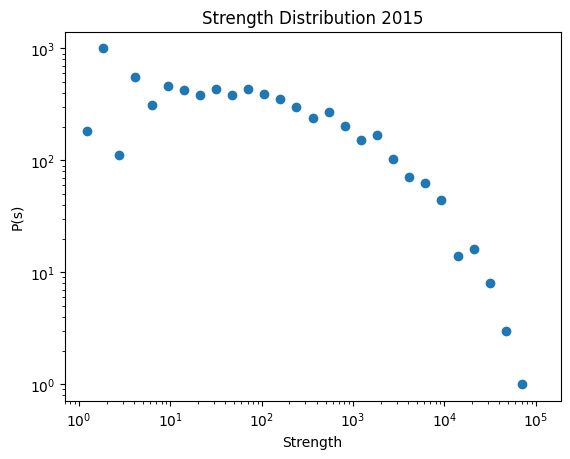

Mean Strength: 502.04398991314093


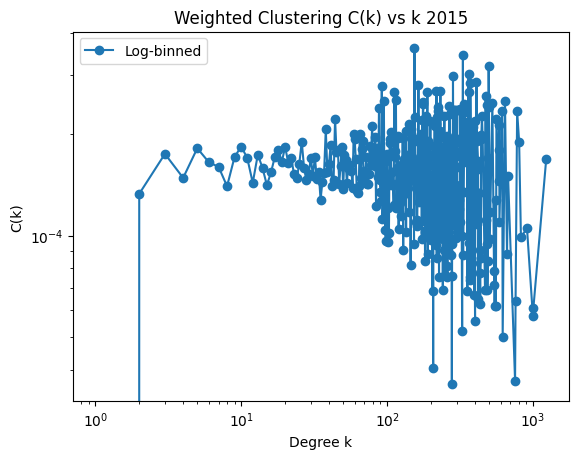

Avg Weighted Clustering: 0.00015506215992010954
Slope of C(k) ~ k^alpha: nan


/tmp/ipykernel_55/1486347067.py:214: RuntimeWarning: divide by zero encountered in log10
  log_c = np.log10(c_vals)


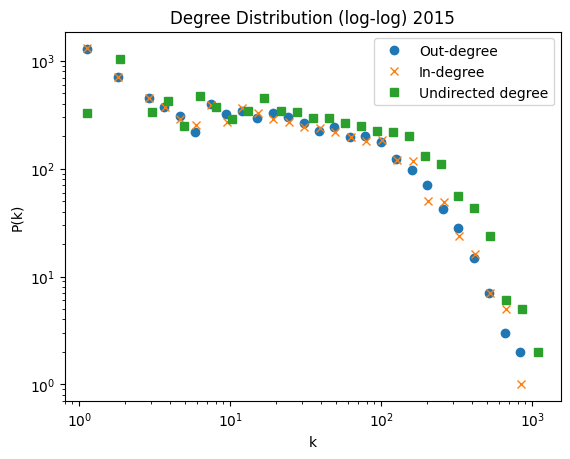

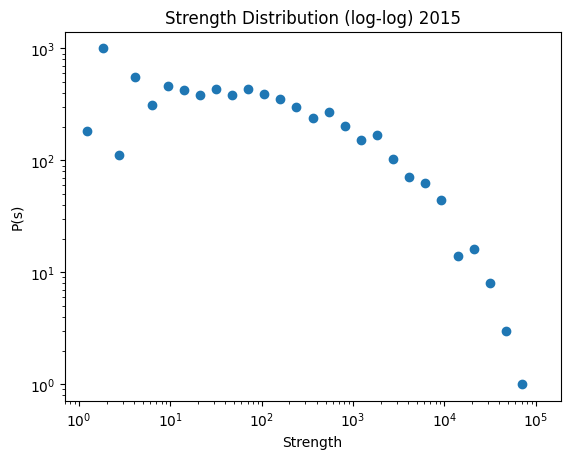


===== Processing 2025 =====

===== WEIGHTED METRICS: 2025 =====
Assortativity (in-in): 0.0023602354853693593
Assortativity (out-out): -0.005308737604076883


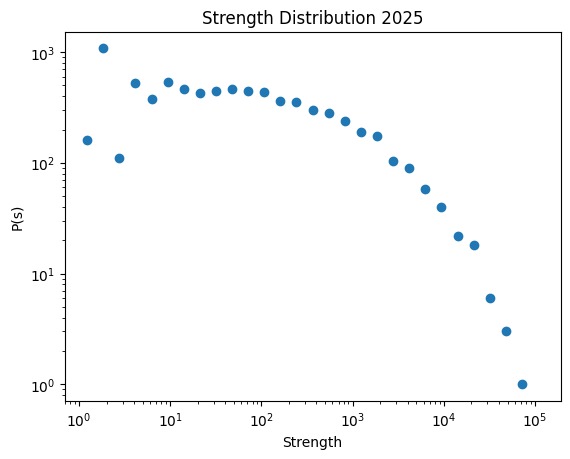

Mean Strength: 504.705957883924


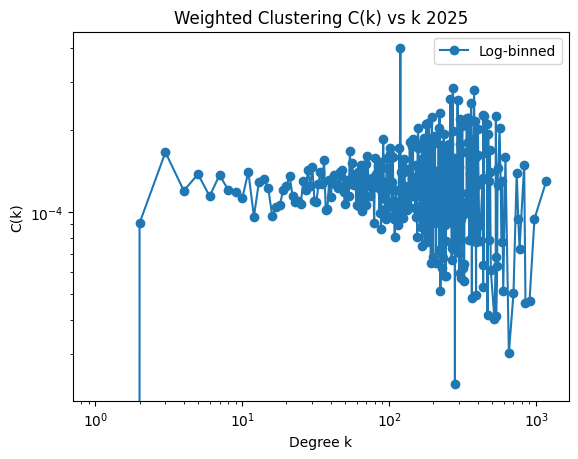

Avg Weighted Clustering: 0.00012451155373430702
Slope of C(k) ~ k^alpha: nan


/tmp/ipykernel_55/1486347067.py:214: RuntimeWarning: divide by zero encountered in log10
  log_c = np.log10(c_vals)


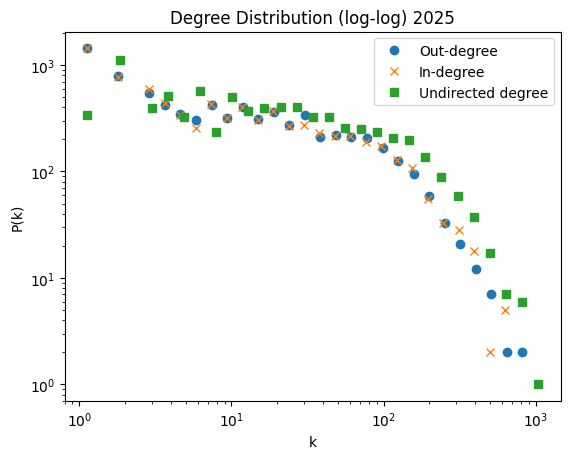

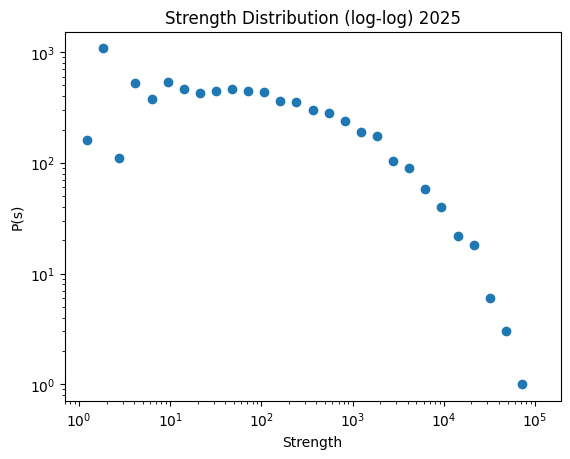

{'nodes_d': 7138, 'edges_d': 188545, 'nodes_u': 7138, 'edges_u': 145745, 'density_d': 0.00370103148353014, 'density_u': 0.00572178348476067, 'avg_clustering_u': 0.5192966804634249, 'avg_clustering_wu': 0.0001497030726479761}
{'nodes_d': 7788, 'edges_d': 182300, 'nodes_u': 7788, 'edges_u': 139499, 'density_d': 0.003006010900524355, 'density_u': 0.004600499337490367, 'avg_clustering_u': 0.48395002534873544, 'avg_clustering_wu': 0.00011431756316809782}
{'node_jaccard': 0.6314351295223521, 'edge_jaccard': 0.2695649494700518, 'common_nodes': 5777, 'common_edges': 78741}


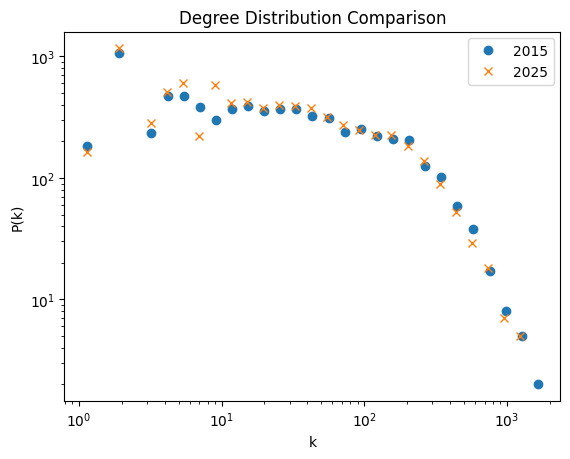

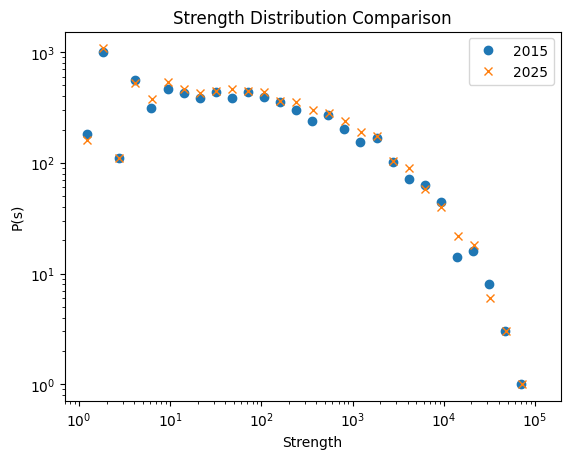

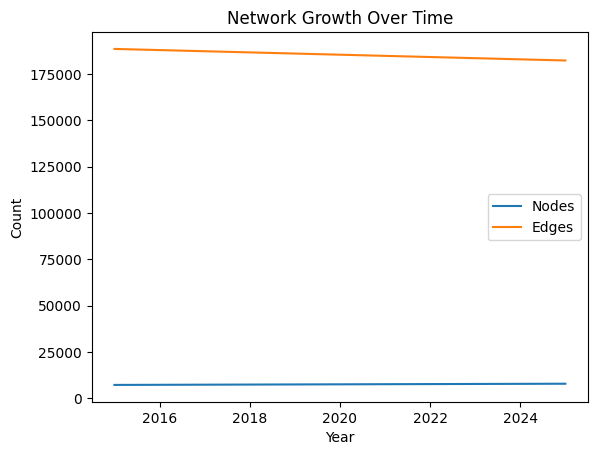

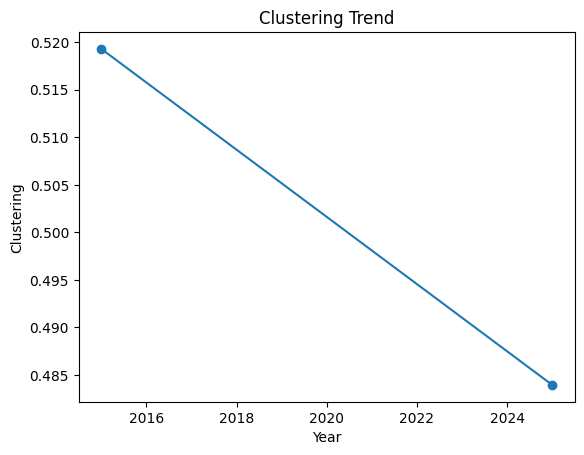

In [10]:
df_2015 = pd.read_csv("/kaggle/input/datasets/debjitbanerji/shipping-data/events_2015_full.csv")
df_2025 = pd.read_csv("/kaggle/input/datasets/debjitbanerji/shipping-data/events_2025_full.csv")

# Convert timestamps
df_2015["entry_time"] = pd.to_datetime(df_2015["entry_time"])
df_2015["exit_time"] = pd.to_datetime(df_2015["exit_time"])
df_2025["entry_time"] = pd.to_datetime(df_2025["entry_time"])
df_2025["exit_time"] = pd.to_datetime(df_2025["exit_time"])

# Sort globally (important)
df_2015 = df_2015.sort_values(["ship_id", "entry_time"])
df_2025 = df_2025.sort_values(["ship_id", "entry_time"])

MIN_TIME_GAP_HRS = 1

df_2015["gap"] = df_2015.groupby("ship_id")["entry_time"].diff().dt.total_seconds() / 3600
df_2025["gap"] = df_2025.groupby("ship_id")["entry_time"].diff().dt.total_seconds() / 3600

df_2015 = df_2015[(df_2015["gap"].isna()) | (df_2015["gap"] < 1000)]  # tune threshold
df_2025 = df_2025[(df_2025["gap"].isna()) | (df_2025["gap"] < 1000)]  # tune threshold

temporal_results = temporal_summary({2015: df_2015, 2025: df_2025})

# ---- Basic comparison ----
print(temporal_results[2015]["basic"])
print(temporal_results[2025]["basic"])

# ---- Overlap ----
print(graph_overlap_metrics(
    temporal_results[2015]["Gd"],
    temporal_results[2025]["Gd"]
))

# ---- Degree comparison ----
compare_degree_distributions(
    temporal_results[2015]["Gd"],
    temporal_results[2025]["Gd"],
    "2015", "2025"
)

# ---- Strength comparison ----
compare_strength_distributions(
    temporal_results[2015]["Gu"],
    temporal_results[2025]["Gu"],
    "2015", "2025"
)

# ---- Trends ----
plot_metric_trends(temporal_results)